In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [3]:
import os

os.listdir(path)

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [4]:
df = pd.read_csv(path+"/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.shape

(7043, 21)

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [10]:
df['Churn'].value_counts(normalize = True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

df['TotalCharges'].dtype

dtype('float64')

In [12]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Missing values after filling:", df['TotalCharges'].isnull().sum())

Missing values after filling: 0


In [14]:
df = df.drop(columns = {'customerID'})

In [15]:
df.shape

(7043, 20)

In [16]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


Churn
No     5174
Yes    1869
Name: count, dtype: int64


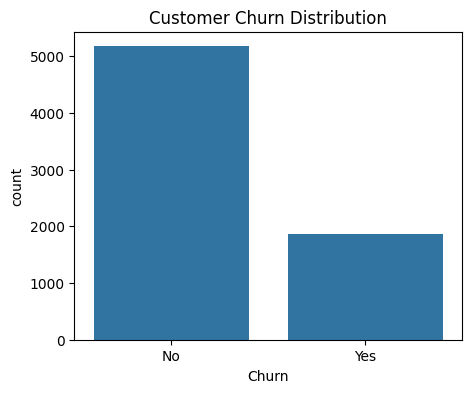

In [17]:
# Churn counts
print(df["Churn"].value_counts())

# Visualization
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [18]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


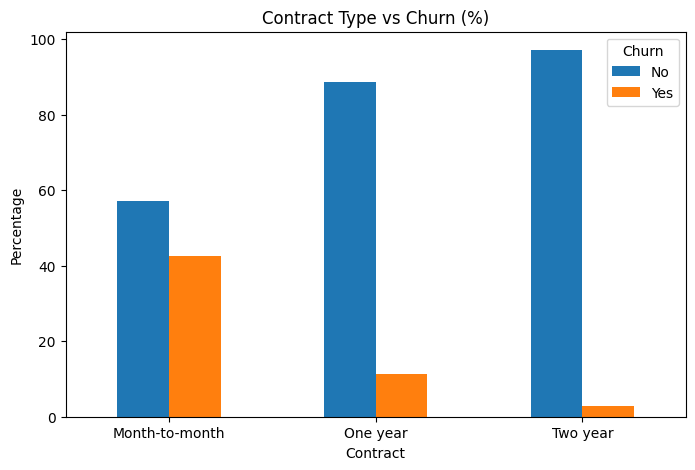

In [19]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Contract Type vs Churn (%)")
plt.ylabel("Percentage")
plt.xticks(rotation = 0)
plt.show()

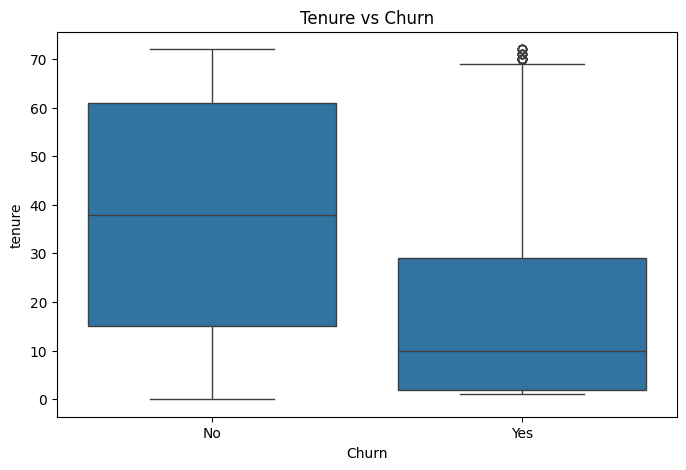

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

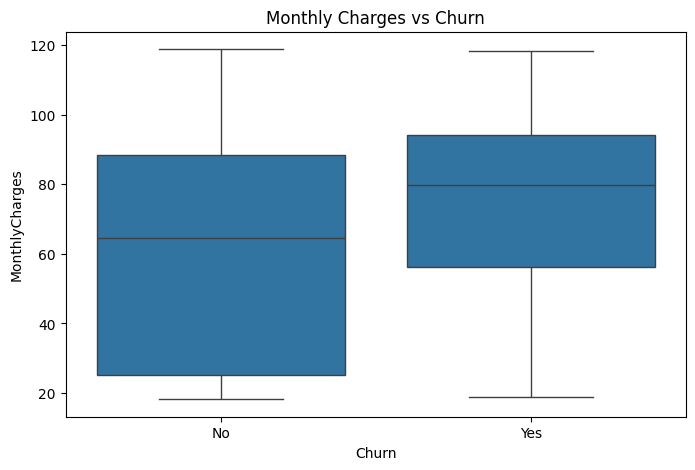

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

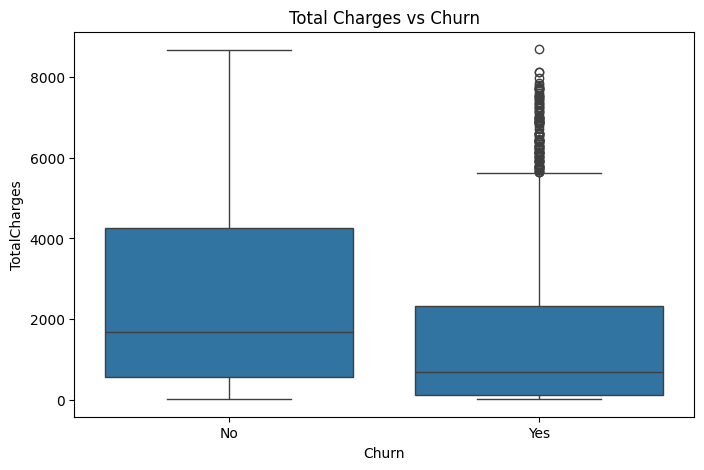

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df
)

plt.title("Total Charges vs Churn")
plt.show()

In [23]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_cols:
    print("\n" + "="*50)
    print(col)

    churn_rate = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100

    print(churn_rate.round(2))


OnlineSecurity
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61

OnlineBackup
Churn                   No    Yes
OnlineBackup                     
No                   60.07  39.93
No internet service  92.60   7.40
Yes                  78.47  21.53

DeviceProtection
Churn                   No    Yes
DeviceProtection                 
No                   60.87  39.13
No internet service  92.60   7.40
Yes                  77.50  22.50

TechSupport
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17

StreamingTV
Churn                   No    Yes
StreamingTV                      
No                   66.48  33.52
No internet service  92.60   7.40
Yes                  69.93  30.07

StreamingMovies
Churn                   No    Yes
StreamingMovies          

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Churn"] = le.fit_transform(df["Churn"])

print(df["Churn"].value_counts())
print(df["Churn"].dtype)

Churn
0    5174
1    1869
Name: count, dtype: int64
int64


In [25]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:")
print(df_encoded.shape)

df_encoded.head()

Shape after encoding:
(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [26]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Completed!")
print("X_train shape:", X_train.shape)

Scaling Completed!
X_train shape: (5634, 30)


In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_2 = Sequential()

model_2.add(
    Dense(
        64,
        activation='relu',
        input_shape=(X_train.shape[1],)
    )
)

model_2.add(
    Dense(
        32,
        activation='relu'
    )
)

model_2.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7648 - loss: 0.4601 - val_accuracy: 0.7906 - val_loss: 0.4393
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8056 - loss: 0.4165 - val_accuracy: 0.7879 - val_loss: 0.4414
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8103 - loss: 0.4077 - val_accuracy: 0.7870 - val_loss: 0.4391
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8143 - loss: 0.4031 - val_accuracy: 0.7888 - val_loss: 0.4361
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8127 - loss: 0.3983 - val_accuracy: 0.7897 - val_loss: 0.4377
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8196 - loss: 0.3944 - val_accuracy: 0.7888 - val_loss: 0.4378
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8232 - loss: 0.3891 - val_accuracy: 0.7844 - val_loss: 0.4414
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8234 - loss: 0.3873 - val_accuracy: 0.

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Predictions
y_pred_prob = model_2.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

# Metrics
acc2 = accuracy_score(y_test, y_pred)
pre2 = precision_score(y_test, y_pred)
rec2 = recall_score(y_test, y_pred)

print("Accuracy :", acc2)
print("Precision:", pre2)
print("Recall   :", rec2)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy : 0.7885024840312278
Precision: 0.6484375
Recall   : 0.44385026737967914

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.65      0.44      0.53       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.77      1409



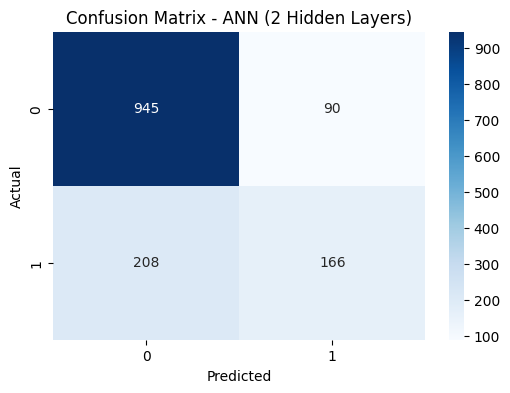

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ANN (2 Hidden Layers)")

plt.show()

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_3 = Sequential()

model_3.add(Dense(
    128,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

model_3.add(Dense(
    64,
    activation='relu'
))

model_3.add(Dense(
    32,
    activation='relu'
))

model_3.add(Dense(
    1,
    activation='sigmoid'
))

model_3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model_3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [35]:
history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7881 - loss: 0.4425 - val_accuracy: 0.7915 - val_loss: 0.4420
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8036 - loss: 0.4116 - val_accuracy: 0.7791 - val_loss: 0.4430
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8130 - loss: 0.4042 - val_accuracy: 0.7968 - val_loss: 0.4374
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8170 - loss: 0.3955 - val_accuracy: 0.7870 - val_loss: 0.4400
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8141 - loss: 0.3911 - val_accuracy: 0.7862 - val_loss: 0.4412
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8236 - loss: 0.3851 - val_accuracy: 0.7844 - val_loss: 0.4442
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8331 - loss: 0.3749 - val_accuracy: 0.7728 - val_loss: 0.4533
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8338 - loss: 0.3689 - val_accuracy: 0.

In [36]:
y_pred_prob = model_3.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

acc3 = accuracy_score(y_test, y_pred)
pre3 = precision_score(y_test, y_pred)
rec3 = recall_score(y_test, y_pred)

print("Accuracy :", acc3)
print("Precision:", pre3)
print("Recall   :", rec3)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy : 0.7352732434350603
Precision: 0.5011441647597255
Recall   : 0.5855614973262032


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_5 = Sequential()

model_5.add(Dense(
    256,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

model_5.add(Dense(128, activation='relu'))
model_5.add(Dense(64, activation='relu'))
model_5.add(Dense(32, activation='relu'))
model_5.add(Dense(16, activation='relu'))

model_5.add(Dense(
    1,
    activation='sigmoid'
))

model_5.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,713 (202.00 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model_5.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [39]:
history_5 = model_5.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7868 - loss: 0.4436 - val_accuracy: 0.7791 - val_loss: 0.4487
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8074 - loss: 0.4125 - val_accuracy: 0.7897 - val_loss: 0.4382
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8185 - loss: 0.4034 - val_accuracy: 0.7897 - val_loss: 0.4410
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8203 - loss: 0.3953 - val_accuracy: 0.7835 - val_loss: 0.4450
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8212 - loss: 0.3916 - val_accuracy: 0.7702 - val_loss: 0.4553
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8247 - loss: 0.3861 - val_accuracy: 0.7808 - val_loss: 0.4439
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8318 - loss: 0.3775 - val_accuracy: 0.7604 - val_loss: 0.4593
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8371 - loss: 0.3685 - val_accuracy: 0.

In [40]:
y_pred_prob = model_5.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

acc5 = accuracy_score(y_test, y_pred)
pre5 = precision_score(y_test, y_pred)
rec5 = recall_score(y_test, y_pred)

print("Accuracy :", acc5)
print("Precision:", pre5)
print("Recall   :", rec5)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy : 0.7579843860894251
Precision: 0.5382830626450116
Recall   : 0.6203208556149733


The objective of this project was to predict customer churn for a telecom company using Artificial Neural Networks (ANNs). Exploratory Data Analysis revealed that customers with month-to-month contracts, low tenure, high monthly charges, and no online security or technical support services were more likely to churn.

Three ANN architectures were developed and compared using 2, 3, and 5 hidden layers. Model performance was evaluated using Accuracy, Precision, and Recall metrics.

The ANN with 2 hidden layers achieved the best overall performance, obtaining 77.43% accuracy and 59.59% precision. Increasing the number of hidden layers resulted in higher training accuracy but lower validation and test performance, indicating overfitting.

The study demonstrates that deeper neural networks do not necessarily improve predictive performance on structured tabular telecom customer data. A simpler ANN architecture provided better generalization and more reliable churn predictions.

The developed model can help telecom companies identify high-risk customers and implement proactive retention strategies, reducing customer loss and improving long-term revenue.


In [41]:
model_2.save("churn_ann_model.keras")

In [42]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']